# Task 1 KNN

## Task 1.1 KNN w/o scikit-learn module
_Important Note_: run using python 3.13.5

1stly we ll add the data

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv("telescope_data.csv")
# print(df)

In [3]:
#   by calculating how much each class (or case) is present we can calculate how much g we need to remove to make the 2 classes equal in size
print(len(df[df['class'] == 'g']) - len(df[df['class'] == 'h']))

5644


Now we need to remove them by:

1- deciding how many we need remove

2- deciding the range we need to remove

3- randomly removing

In [4]:
remove_num = len(df[df['class'] == 'g']) - len(df[df['class'] == 'h'])    #   the amount we want to remove
index_last = len(df[df['class'] == 'g']) - 1                              #   the last index of g, since the data is in order
np.random.seed(69)
drop_indices = np.random.choice(index_last, remove_num, replace=False)
df = df.drop(drop_indices)

#double check
if len(df[df['class'] == 'g']) == len(df[df['class'] == 'h']):
    print("success!")

success!


now we will devide the data frame into training set (70%), validation set (15%) and a test set (15%)

we can use this by taking the top 70% of each class to the training set, the middle 15% to the validation set and the bottom 15% to the test set

this means that we training set will consists of the entries from index 0 to index_point1 and

In [5]:
index_point1 = int((len(df)/2) * 0.7)
index_point2 = int((len(df)/2) * (0.7+0.15))
index_point3 = int(len(df)/2)
# print(index_point1)
# print(index_point2)
# print(int(len(df)/2))

df_train = pd.concat([df[0: index_point1].copy(), df[index_point3: index_point3+index_point1].copy()])

df_validate = pd.concat([df[index_point1: index_point2].copy(), df[index_point3+index_point1: index_point3+index_point2]])

df_test = pd.concat([df[index_point2: index_point3].copy(), df[index_point3+index_point2: index_point3+index_point3]])

#   double check
if len(df_train[df_train['class'] == 'g']) == len(df_train[df_train['class'] == 'h']):
    print("train success")
if len(df_validate[df_validate['class'] == 'g']) == len(df_validate[df_validate['class'] == 'h']):
    print("validate success")
if len(df_test[df_test['class'] == 'g']) == len(df_test[df_test['class'] == 'h']):
    print("test success")

train success
validate success
test success


Minimum percentage error:  22.482552342971086 %
at k =  51


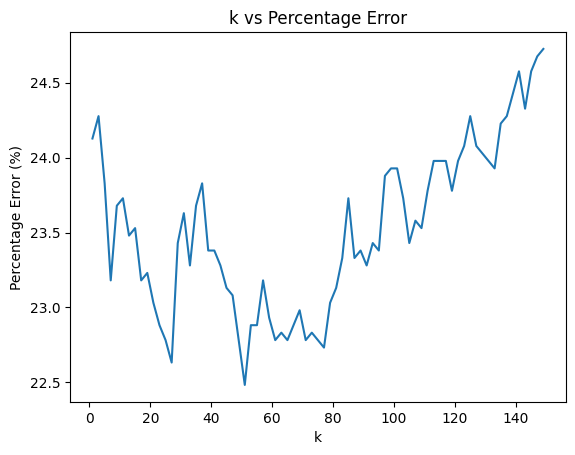

In [6]:
# Matricesssssssssssssssss

import matplotlib.pyplot as plt

features = [
    "fLength", "fWidth", "fSize", "fConc", "fConc1",
    "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist"
]

X_train = df_train[features].values
y_train = df_train["class"].values
X_val = df_validate[features].values
y_val = df_validate["class"].values

k_arr = []
pev_arr = []

# tru_amnt = 0
# err_amnt = 0
# k = 5

for k in range(1, 150, 2):
    tru_amnt = 0
    err_amnt = 0
    for val_i in range(len(X_val)):
        # Compute squared Euclidean distances to all training points
        diff = X_train - X_val[val_i]
        dists = np.sum(diff ** 2, axis=1)
        # Find indices of k nearest neighbors
        knn_idx = np.argpartition(dists, k)[:k]
        knn_classes = y_train[knn_idx]
        # Majority vote
        pred_class = pd.Series(knn_classes).mode()[0]
        if pred_class == y_val[val_i]:
            tru_amnt += 1
        else:
            err_amnt += 1
    # print(f"k = {k}, true = {tru_amnt}, error = {err_amnt}, percentage error = {err_amnt / (tru_amnt + err_amnt) * 100:.2f}%")
    k_arr.append(k)
    pev_arr.append(err_amnt / (tru_amnt + err_amnt) * 100)

plt.plot(k_arr, pev_arr)
plt.xlabel("k")
plt.ylabel("Percentage Error (%)")
plt.title("k vs Percentage Error")

print("Minimum percentage error: ", min(pev_arr), "%\nat k = ", k_arr[pev_arr.index(min(pev_arr))])


# ...existing code...

In [7]:
# test with k = 51

features = [
    "fLength", "fWidth", "fSize", "fConc", "fConc1",
    "fAsym", "fM3Long", "fM3Trans", "fAlpha", "fDist"
]

X_train = df_train[features].values
y_train = df_train["class"].values
X_test = df_test[features].values
y_test = df_test["class"].values

k_arr = []
pet_arr = []

k = 51  # the one with the lowest percentage error
pred = []

tru_amnt = 0
err_amnt = 0
for test_i in range(len(X_test)):
    # Compute squared Euclidean distances to all training points
    diff = X_train - X_test[test_i]
    dists = np.sum(diff ** 2, axis=1)
    # Find indices of k nearest neighbors
    knn_idx = np.argpartition(dists, k)[:k]
    knn_classes = y_train[knn_idx]
    # Majority vote
    pred_class = pd.Series(knn_classes).mode()[0]
    if pred_class == y_test[test_i]:
        tru_amnt += 1
    else:
        err_amnt += 1

    pred.append(pred_class)

## calculation
for the sake of simplicity we ll use the scikit learn built in functions

In [8]:
# accuracy
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, pred)
print(f"Accuracy: {accuracy * 100:.2f}%")

# precision
from sklearn.metrics import precision_score

precision = precision_score(y_test, pred, pos_label='g')
print(f"Precision: {precision * 100:.2f}%")

# recall
from sklearn.metrics import recall_score

recall = recall_score(y_test, pred, pos_label='g')
print(f"Recall: {recall * 100:.2f}%")

# F1 score
from sklearn.metrics import f1_score

f1 = f1_score(y_test, pred, pos_label='g')
print(f"F1 Score: {f1 * 100:.2f}%")

# confusion matrix
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, pred)
print(cm)

Accuracy: 77.54%
Precision: 73.06%
Recall: 87.25%
F1 Score: 79.53%
[[876 128]
 [323 681]]
